First Best

Nombre de caractéristiques sélectionnées : 22
Caractéristiques sélectionnées : ['Gender', 'Jitter_RAP', 'Jitter_PPQ', 'Shim_APQ3', 'Shi_APQ11', 'HNR15', 'HNR35', 'RPDE', 'MFCC2', 'MFCC4', 'MFCC9', 'MFCC10', 'Delta0', 'Delta1', 'Delta3', 'Delta5', 'Delta6', 'Delta7', 'Delta8', 'Delta9', 'Delta11', 'Delta12']


Résultats avec Wrapper-Based (MLP base) + First Best :
      Classifier  Accuracy  Precision    Recall   F-score
0    Naïve Bayes  0.837500   0.858407  0.808333  0.832618
1          c-SVM  0.820833   0.840708  0.791667  0.815451
2         nu-SVM  0.820833   0.823529  0.816667  0.820084
3            MLP  0.825000   0.819672  0.833333  0.826446
4            KNN  0.825000   0.825000  0.825000  0.825000
5  Random Forest  0.804167   0.823009  0.775000  0.798283


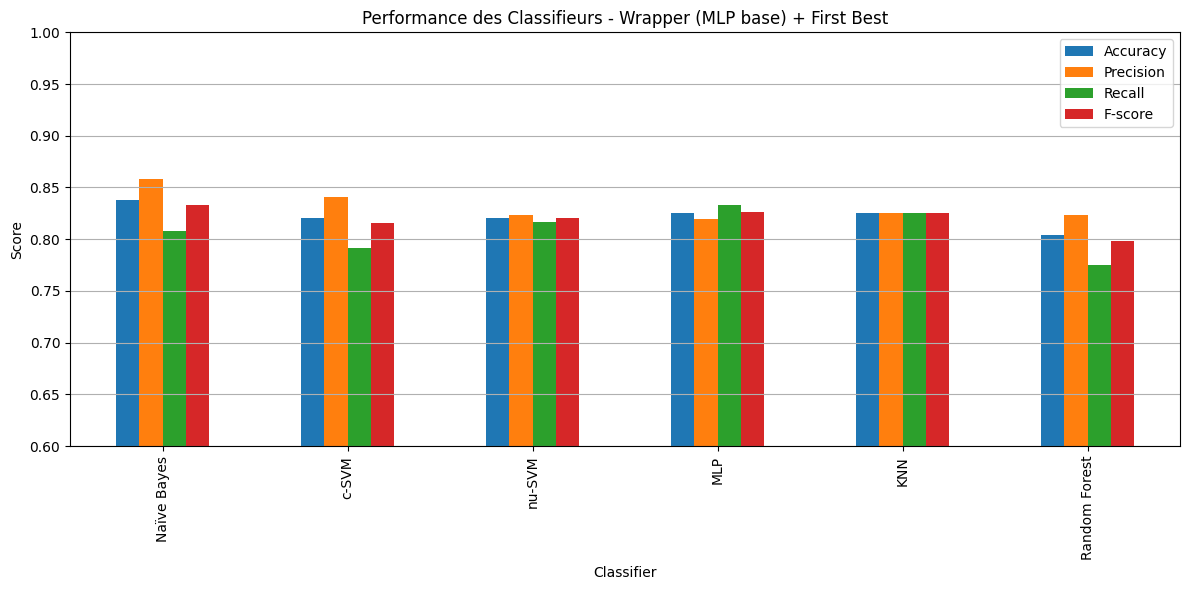

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Chargement des données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=["ID", "Recording", "Status"])
X = pd.get_dummies(X, drop_first=True)
y = df["Status"]

# 2. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Sélection de caractéristiques avec MLP (First Best - forward)
mlp_base = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)

sfs = SequentialFeatureSelector(
    mlp_base,
    n_features_to_select="auto",
    direction='forward',
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

X_selected = sfs.fit_transform(X_scaled, y)
selected_features = X.columns[sfs.get_support()]
print(f"Nombre de caractéristiques sélectionnées : {len(selected_features)}")
print(f"Caractéristiques sélectionnées : {list(selected_features)}\n")

# 4. Définir les classificateurs
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "c-SVM": SVC(C=1.0, kernel='rbf'),
    "nu-SVM": NuSVC(nu=0.5, kernel='rbf'),
    "MLP": MLPClassifier(hidden_layer_sizes=(50,), max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 5. Validation croisée et évaluation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

for name, clf in classifiers.items():
    y_pred = cross_val_predict(clf, X_selected, y, cv=cv)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    results.append([name, acc, prec, rec, f1])

# 6. Affichage des résultats
results_df = pd.DataFrame(results, columns=["Classifier", "Accuracy", "Precision", "Recall", "F-score"])
print("\nRésultats avec Wrapper-Based (MLP base) + First Best :")
print(results_df)

# 7. Graphique comparatif
results_df.set_index("Classifier")[["Accuracy", "Precision", "Recall", "F-score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Performance des Classifieurs - Wrapper (MLP base) + First Best")
plt.ylabel("Score")
plt.ylim(0.6, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Greedy StepWise

Nombre de caractéristiques sélectionnées : 23
Caractéristiques sélectionnées : ['Jitter_RAP', 'Jitter_PPQ', 'HNR05', 'HNR15', 'HNR35', 'PPE', 'GNE', 'MFCC0', 'MFCC1', 'MFCC2', 'MFCC3', 'MFCC4', 'MFCC7', 'MFCC8', 'MFCC9', 'MFCC10', 'Delta2', 'Delta3', 'Delta4', 'Delta6', 'Delta7', 'Delta11', 'Delta12']


Résultats avec Wrapper-Based (MLP base) + Greedy StepWise :


,Classifier,Accuracy,Precision,Recall,F-score
0,Naïve Bayes,0.787500,0.810811,0.750000,0.779221
1,c-SVM,0.820833,0.846847,0.783333,0.813853
2,nu-SVM,0.816667,0.827586,0.800000,0.813559
3,MLP,0.783333,0.783333,0.783333,0.783333
4,KNN,0.812500,0.820513,0.800000,0.810127
5,Random Forest,0.808333,0.830357,0.775000,0.801724


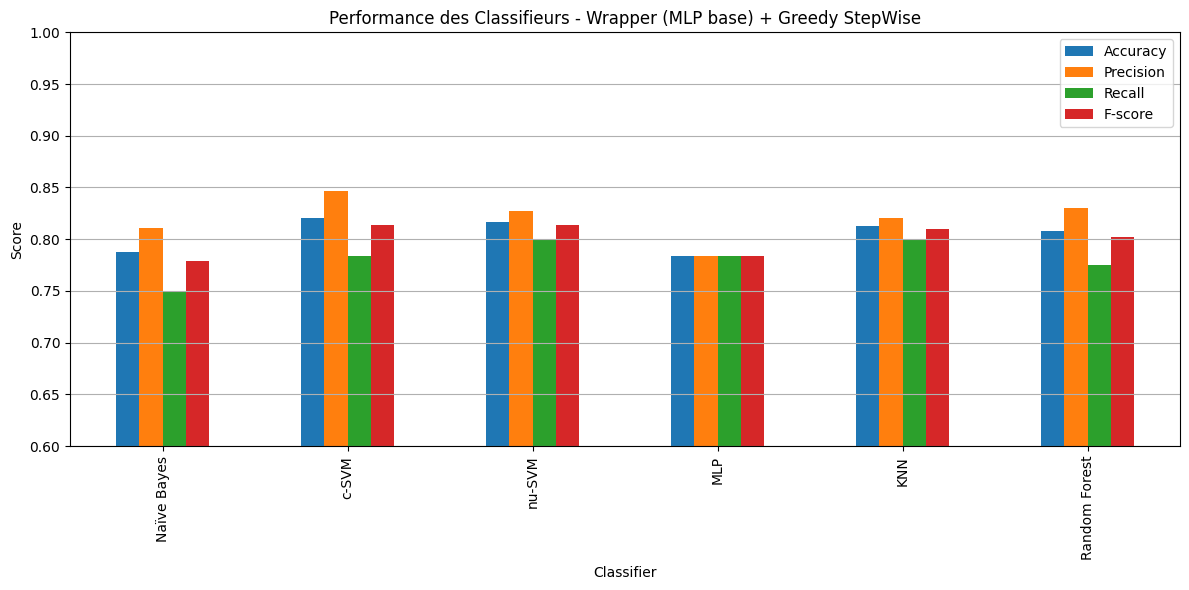

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Chargement des données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=["ID", "Recording", "Status"])
X = pd.get_dummies(X, drop_first=True)
y = df["Status"]

# 2. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Sélection de caractéristiques avec MLP (Greedy StepWise - BackWard)
mlp_base = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)

sfs = SequentialFeatureSelector(
    mlp_base,
    n_features_to_select="auto",
    direction='backward',
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

X_selected = sfs.fit_transform(X_scaled, y)
selected_features = X.columns[sfs.get_support()]
print(f"Nombre de caractéristiques sélectionnées : {len(selected_features)}")
print(f"Caractéristiques sélectionnées : {list(selected_features)}\n")

# 4. Définir les classificateurs
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "c-SVM": SVC(C=1.0, kernel='rbf'),
    "nu-SVM": NuSVC(nu=0.5, kernel='rbf'),
    "MLP": MLPClassifier(hidden_layer_sizes=(50,), max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 5. Validation croisée et évaluation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

for name, clf in classifiers.items():
    y_pred = cross_val_predict(clf, X_selected, y, cv=cv)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    results.append([name, acc, prec, rec, f1])

# 6. Affichage des résultats
results_df = pd.DataFrame(results, columns=["Classifier", "Accuracy", "Precision", "Recall", "F-score"])
print("\nRésultats avec Wrapper-Based (MLP base) + Greedy StepWise :")
display(results_df)

# 7. Graphique comparatif
results_df.set_index("Classifier")[["Accuracy", "Precision", "Recall", "F-score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Performance des Classifieurs - Wrapper (MLP base) + Greedy StepWise")
plt.ylabel("Score")
plt.ylim(0.6, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


PSO

2025-06-20 15:52:34,971 - pyswarms.discrete.binary - INFO - Optimize for 30 iters with {'c1': 2, 'c2': 2, 'w': 0.9, 'k': 3, 'p': 2}
pyswarms.discrete.binary: 100%|██████████|30/30, best_cost=0.202
2025-06-20 16:43:45,973 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.2016012995587606, best pos: [0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1 1 1 1 0 0 0 0 1 0
 0 0 0 1 0 0 1 0]


      Classifier  Accuracy  Precision    Recall  F1-score
0    Naïve Bayes  0.825000   0.843970  0.825000  0.819564
1          C-SVM  0.808333   0.824683  0.808333  0.803036
2         Nu-SVM  0.804167   0.821201  0.804167  0.798775
3            MLP  0.804167   0.829071  0.804167  0.798399
4           K-NN  0.783333   0.794516  0.783333  0.778193
5  Random Forest  0.791667   0.807628  0.791667  0.781682


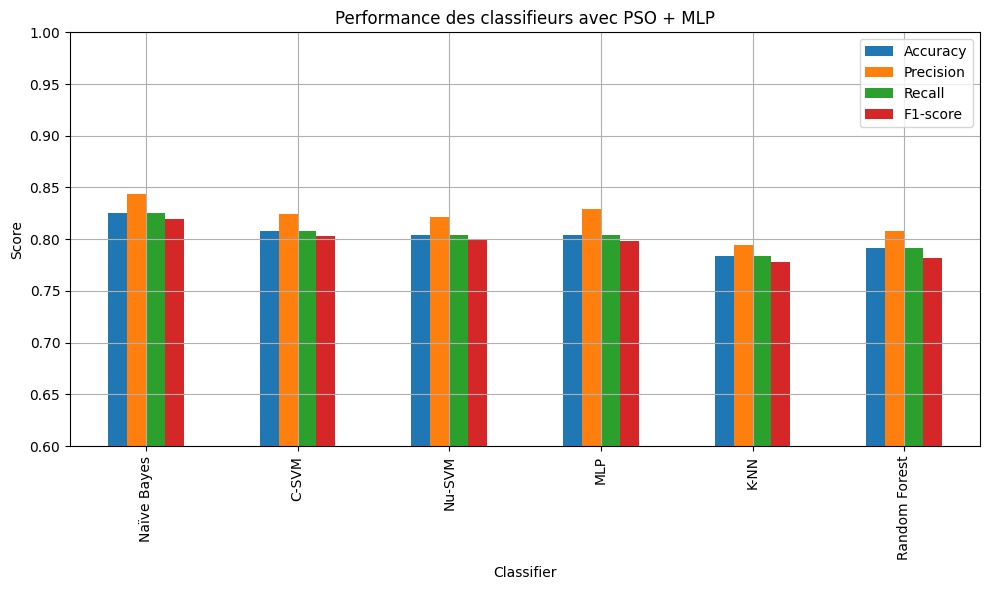

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from pyswarms.discrete import BinaryPSO

# 1. Charger les données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=["ID", "Recording", "Status"])
X = pd.get_dummies(X, drop_first=True)
y = df["Status"]

# 2. Standardiser
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Définir le classifieur de base (MLP)
base_clf = MLPClassifier(hidden_layer_sizes=(50,), max_iter=2000, random_state=42)
cv = StratifiedKFold(n_splits=10)

# 4. Fonction objectif pour PSO (maximiser F1-macro)
def objective_function(mask):
    scores = []
    for m in mask:
        if np.count_nonzero(m) == 0:
            scores.append(0)
            continue
        X_selected = X_scaled[:, m.astype(bool)]
        f1 = cross_val_score(base_clf, X_selected, y, cv=cv, scoring='f1_macro').mean()
        scores.append(1 - f1)  # minimiser l'erreur = 1 - score
    return np.array(scores)

# 5. Lancer PSO
dimensions = X.shape[1]
options = {'c1': 2, 'c2': 2, 'w': 0.9, 'k': 3, 'p': 2}
optimizer = BinaryPSO(n_particles=20, dimensions=dimensions, options=options)
cost, best_mask = optimizer.optimize(objective_function, iters=30, verbose=True)

# 6. Appliquer le meilleur sous-ensemble
X_best = X_scaled[:, best_mask.astype(bool)]

# 7. Évaluer les classifieurs
models = {
    "Naïve Bayes": GaussianNB(),
    "C-SVM": SVC(kernel='rbf', C=1.0),
    "Nu-SVM": NuSVC(nu=0.5, kernel='rbf'),
    "MLP": MLPClassifier(hidden_layer_sizes=(50,), max_iter=2000, random_state=42),
    "K-NN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    scores = cross_val_score(model, X_best, y, cv=cv, scoring='accuracy')
    accuracy = scores.mean()
    precision = cross_val_score(model, X_best, y, cv=cv, scoring='precision_macro').mean()
    recall = cross_val_score(model, X_best, y, cv=cv, scoring='recall_macro').mean()
    f1 = cross_val_score(model, X_best, y, cv=cv, scoring='f1_macro').mean()
    results.append({
        "Classifier": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

# 8. Afficher tableau + graphique
df_results = pd.DataFrame(results)
print(df_results)

df_results.set_index("Classifier")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind='bar', figsize=(10,6), title="Performance des classifieurs avec PSO + MLP")
plt.ylabel("Score")
plt.ylim(0.6, 1)
plt.grid(True)
plt.tight_layout()
plt.show()
